In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt

import matplotlib.pyplot as plt
import time

# Set random seed for reproducibility
rng = np.random.default_rng(12345)

In [2]:
#!pip3 install -U ucimlrepo 

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
X = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets 
  
# metadata 
print(statlog_german_credit_data.metadata) 
  
# variable information 
display(statlog_german_credit_data.variables) 

{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

,name,role,type,demographic,description,units,missing_values
0,Attribute1,Feature,Categorical,None,Status of existing checking account,None,no
1,Attribute2,Feature,Integer,None,Duration,months,no
2,Attribute3,Feature,Categorical,None,Credit history,None,no
3,Attribute4,Feature,Categorical,None,Purpose,None,no
4,Attribute5,Feature,Integer,None,Credit amount,None,no
5,Attribute6,Feature,Categorical,None,Savings account/bonds,None,no
6,Attribute7,Feature,Categorical,Other,Present employment since,None,no
7,Attribute8,Feature,Integer,None,Installment rate in percentage of disposable i...,None,no
8,Attribute9,Feature,Categorical,Marital Status,Personal status and sex,None,no
9,Attribute10,Feature,Categorical,None,Other debtors / guarantors,None,no


In [4]:
X

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,4,A121,31,A143,A152,1,A172,1,A191,A201
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,4,A122,40,A143,A152,1,A174,1,A192,A201
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,4,A124,23,A143,A153,1,A173,1,A192,A201


In [5]:
y

,class
0,1
1,2
2,1
3,1
4,2
...,...
995,1
996,1
997,1
998,2


In [6]:
numerical_data = "statlog+german+credit+data/german.data-numeric"
df = pd.read_csv(numerical_data, sep=r"\s+", header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4,12,2,17,1,4,2,4,1,31,...,0,0,1,0,0,1,0,1,0,1
996,1,30,2,39,1,3,1,4,2,40,...,0,1,1,0,0,1,0,0,0,1
997,4,12,2,8,1,5,3,4,3,38,...,0,0,1,0,0,1,0,0,1,1
998,1,45,2,18,1,3,3,4,4,23,...,0,0,1,0,0,0,0,0,1,2


The target distribution is
p(α, β|x, y) ∝ p(y|x, α, β)p(α)p(β)
$$
P \propto
\exp\left(
-\sum_{i}\log\!\left(1+\exp\!\left\{-y_i\left(\alpha + x_i \cdot \beta\right)\right\}\right)
-\frac{\alpha^2}{2\sigma^2}
-\frac{1}{2\sigma^2}\,\beta \cdot \beta
\right)
$$

In [7]:
# The 25th column, with index 24, is actually just y, so I drop it from the dataframe
print("25th column - y: ", np.sum( df[24]-y["class"] ) )
df = df.iloc[:, :24]
print("Dataframe shape: ", df.shape)

# "All predictors are normalized to have zero mean and unit variance"
df_norm = (df - df.mean())/df.std()
display( df_norm )

# "yi is −1 if customer i should be denied credit and 1 if that customer should receive credit"
y_credit = np.where(y["class"]==1, 1, -1)

25th column - y:  0
Dataframe shape:  (1000, 24)


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,-1.253938,-1.235859,1.343342,-0.733065,1.832252,1.337409,0.449102,1.046463,-1.293076,2.765073,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
1,-0.458797,2.247070,-0.503176,0.965893,-0.699357,-0.317800,-0.963168,-0.765594,-1.293076,-1.190808,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
2,1.131486,-0.738298,1.343342,-0.414510,-0.699357,0.509805,0.449102,0.140434,-1.293076,1.182721,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,1.99900,-1.304224
3,-1.253938,1.749509,-0.503176,1.638398,-0.699357,0.509805,0.449102,1.046463,-0.340885,0.831087,...,-0.195916,-0.552429,-0.338692,-3.121368,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973
4,-1.253938,0.256825,0.420083,0.576549,-0.699357,-0.317800,0.449102,1.046463,1.563498,1.534354,...,-0.195916,1.808378,-0.338692,0.320052,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.131486,-0.738298,-0.503176,-0.556090,-0.699357,0.509805,-0.963168,1.046463,-1.293076,-0.399632,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,1.99900,-1.304224
996,-1.253938,0.754386,-0.503176,0.222599,-0.699357,-0.317800,-2.375438,1.046463,-0.340885,0.391544,...,-0.195916,-0.552429,2.949581,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,-1.304224
997,1.131486,-0.738298,-0.503176,-0.874645,-0.699357,1.337409,0.449102,1.046463,0.611307,0.215727,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
998,-1.253938,1.998289,-0.503176,-0.520695,-0.699357,-0.317800,0.449102,1.046463,1.563498,-1.102900,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973


In [8]:
# "α and each element of β are given weak zero-mean normal priors with variance σ^2 = 100"
prior_mean = 0
prior_var = 100

TARGET_ACCEPT = 0.9

with pm.Model() as model:
    X_data = pm.Data( "X", df_norm )
    y_data = pm.Data( "y", y_credit )

    # Priors
    alpha = pm.Normal( "alpha", mu=0.0, sigma=np.sqrt(prior_var) )
    beta  = pm.Normal( "beta",  mu=0.0, sigma=np.sqrt(prior_var), shape=X_data.shape[1] )

    # eta_i = alpha + x_i * beta
    eta = alpha + pt.dot( X_data, beta )

    # log-likelihood: -sum_i log(1 + exp(-y_i * eta_i))
    # log1p is log(1+...) and is more numerically stable
    loglike = -pt.sum( pt.log1p( pt.exp( -y_data * eta ) ) )

    pm.Potential("likelihood", loglike)

    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=TARGET_ACCEPT,
        random_seed=2026,
        progressbar = True,
        nuts_sampler = "pymc"
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.219,0.094,1.053,1.404,0.001,0.001,5424.944,2907.642,1.000
beta[0],0.745,0.092,0.585,0.933,0.001,0.002,7135.623,3182.378,1.001
beta[1],-0.423,0.105,-0.618,-0.226,0.001,0.002,5473.341,2972.165,1.001
beta[2],0.419,0.100,0.230,0.600,0.001,0.001,6914.788,3716.862,1.001
beta[3],-0.126,0.107,-0.333,0.070,0.001,0.002,5143.956,2917.570,1.000
beta[4],0.373,0.096,0.198,0.558,0.001,0.002,6646.679,2572.123,1.001
beta[5],0.180,0.093,0.008,0.356,0.001,0.002,6436.169,2950.900,1.001
beta[6],0.155,0.083,-0.002,0.313,0.001,0.001,7346.807,2691.914,1.001
beta[7],-0.013,0.092,-0.185,0.162,0.001,0.001,8095.482,3205.812,1.000
beta[8],-0.182,0.104,-0.372,0.010,0.001,0.001,5743.620,3174.317,1.000


Number of parameters with R_hat > 1.05: 0


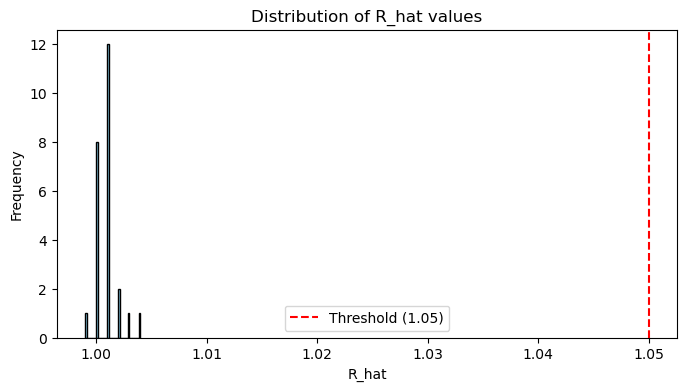

Number of parameters with ESS_bulk < 400: 0
Number of divergences: 0


In [9]:
summary_nuts = az.summary(idata, var_names=["alpha", "beta"], round_to=3)
display(summary_nuts)

# 1) Count how many rows exceed R_hat > 1.05
rhat_exceed = (summary_nuts['r_hat'] > 1.05).sum()
print(f"Number of parameters with R_hat > 1.05: {rhat_exceed}")

# 2) Plot the distribution of R_hat
plt.figure(figsize=(8, 4))
plt.hist(summary_nuts['r_hat'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(1.05, color='red', linestyle='--', label='Threshold (1.05)')
plt.title('Distribution of R_hat values')
plt.xlabel('R_hat')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 3) Check ESS (Effective Sample Size)
# Generally, we look at 'ess_bulk' or 'ess_tail'
# A common rule of thumb is ESS > 100 * number of chains (e.g., 400)
ess_threshold = 400
low_ess = (summary_nuts['ess_bulk'] < ess_threshold).sum()
print(f"Number of parameters with ESS_bulk < {ess_threshold}: {low_ess}")

# Optional: Display parameters that failed the checks
if rhat_exceed > 0:
    print("\nParameters with R_hat > 1.05:")
    print(summary_nuts[summary_nuts['r_hat'] > 1.05])

print("Number of divergences:", int(idata.sample_stats["diverging"].sum()))

/home/mattia/anaconda3/envs/alice/lib/python3.13/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='beta\n0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='beta\n0', ylabel='beta\n7'>,
        <Axes: xlabel='beta\n1'>, <Axes: xlabel='beta\n2'>,
        <Axes: xlabel='beta\n3'>, <Axes: xlabel='beta\n4'>,
        <Axes: xlabel='beta\n5'>, <Ax

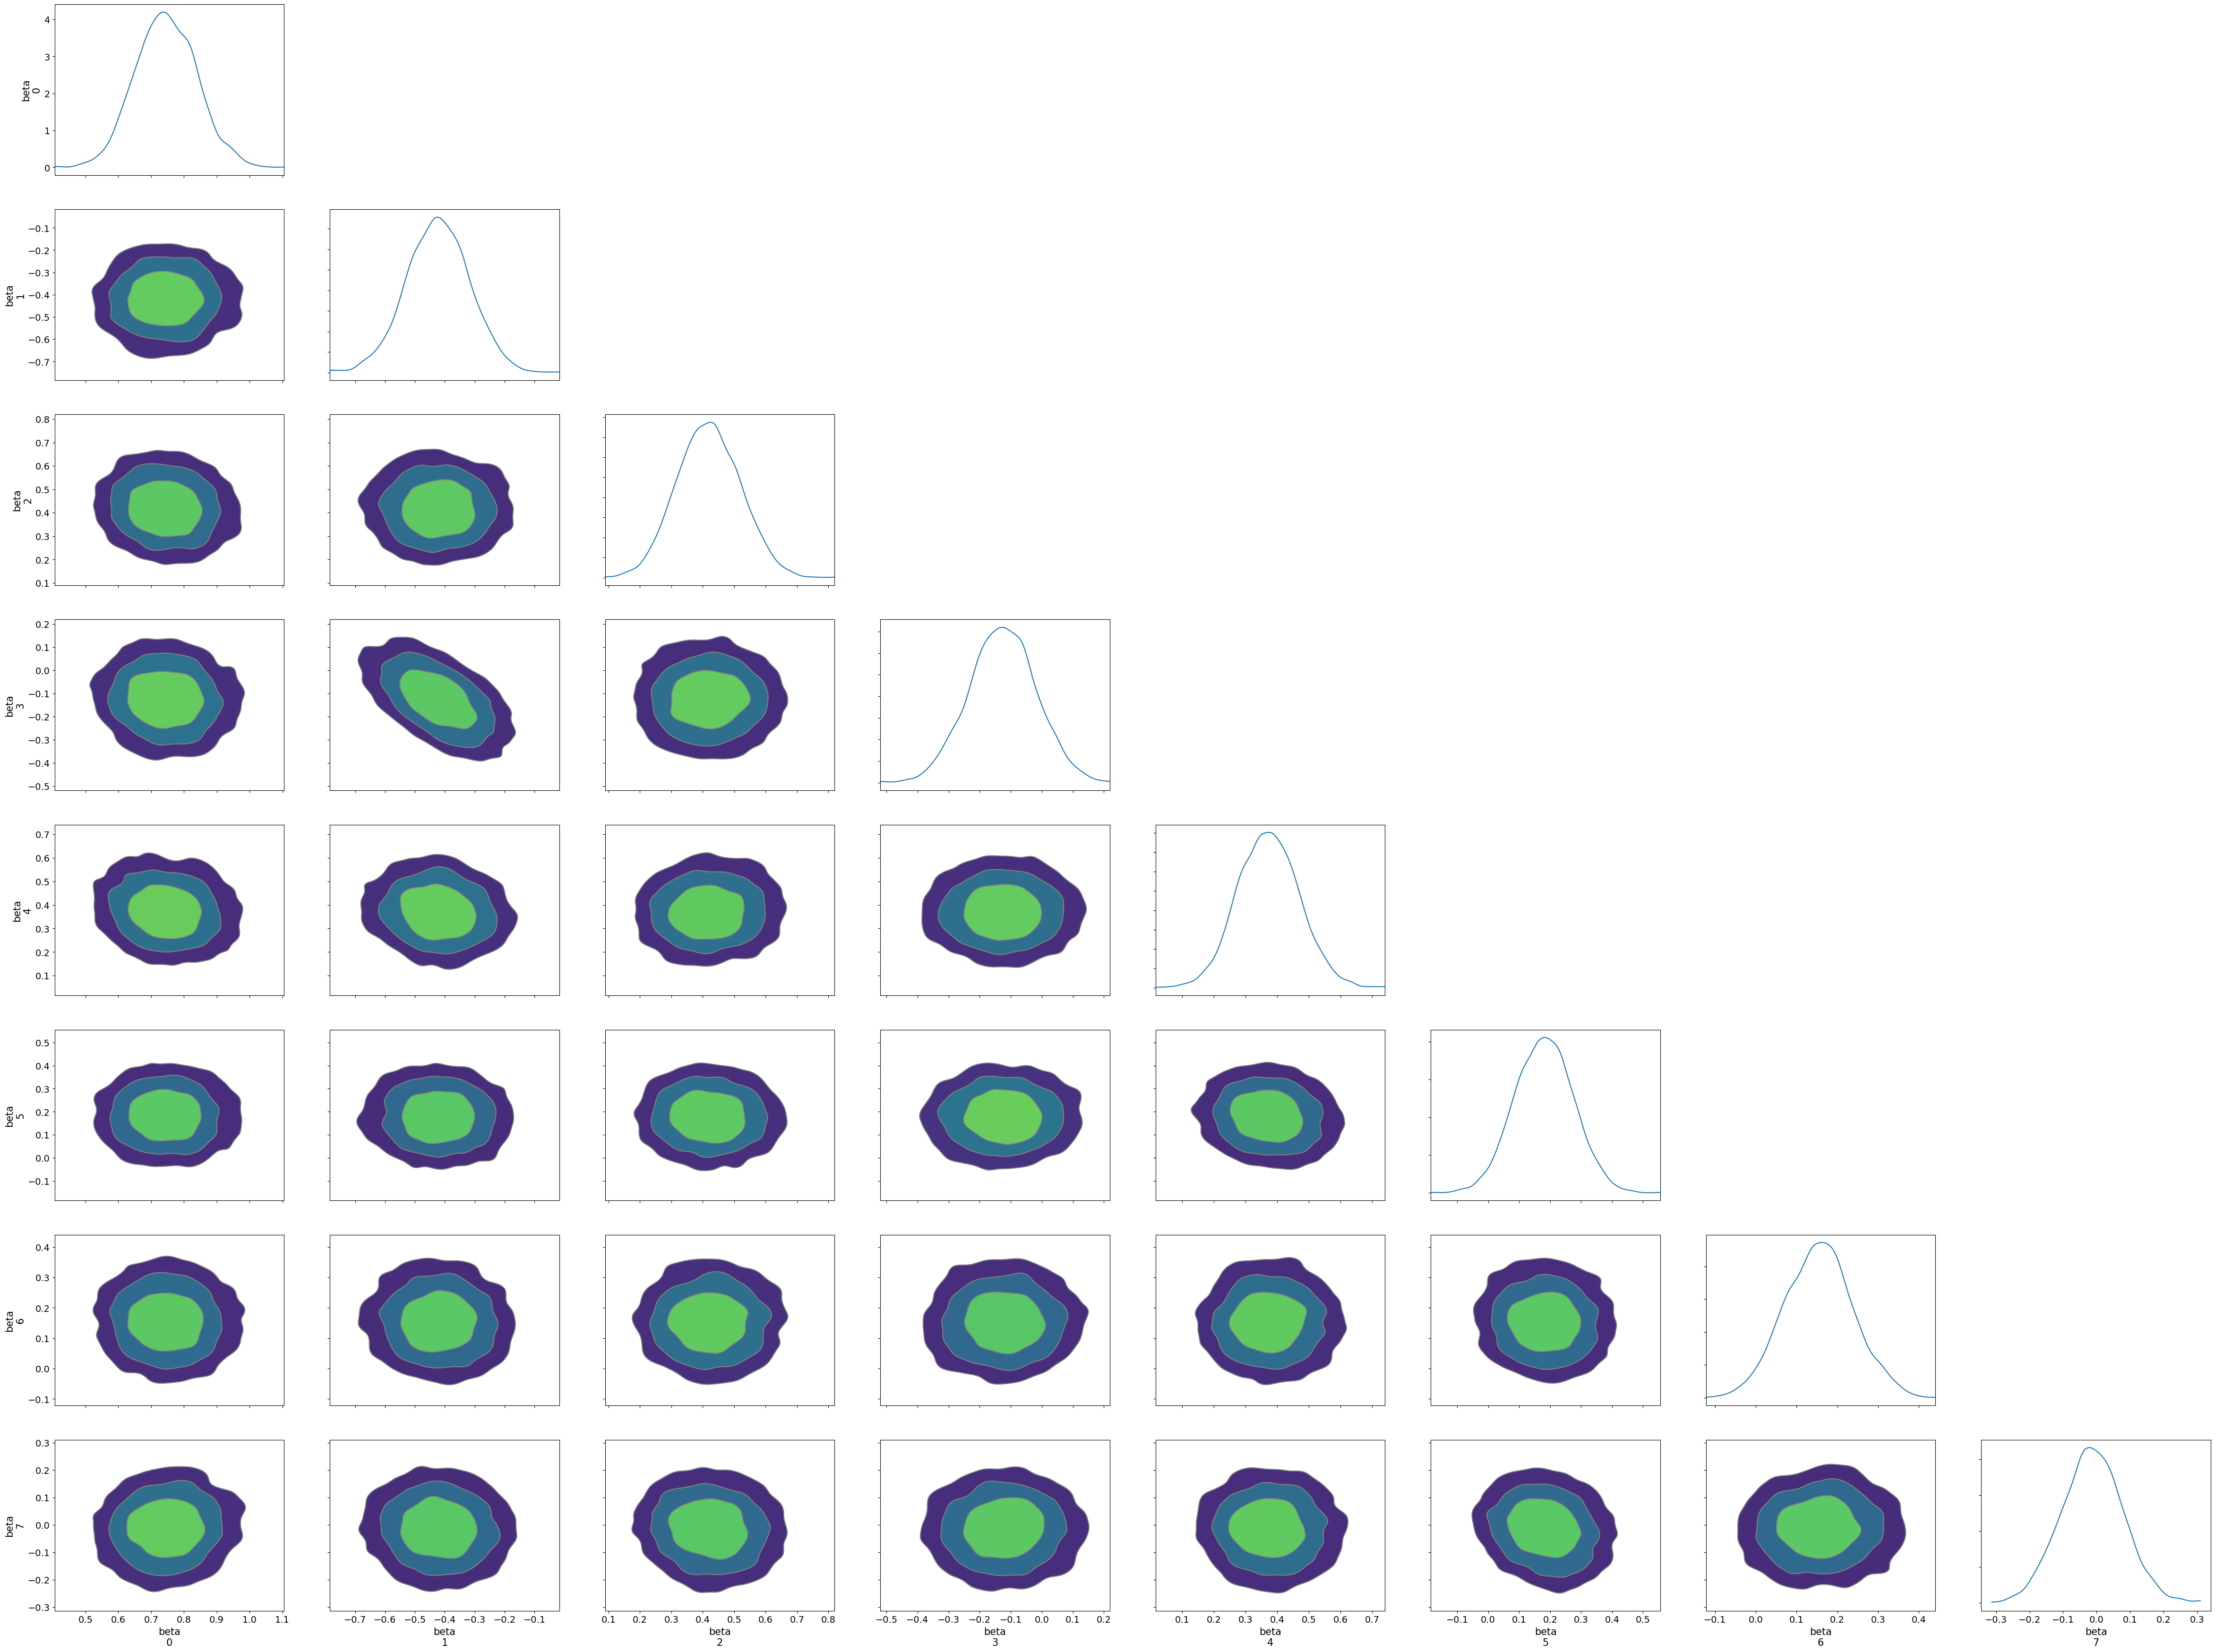

In [10]:
az.plot_pair(idata, var_names=["beta"], kind="kde", marginals=True)

In [11]:
idata.sample_stats["acceptance_rate"]

<xarray.DataArray 'acceptance_rate' (chain: 4, draw: 1000)> Size: 32kB
array([[0.94803461, 0.90756544, 0.92402579, ..., 0.84731948, 0.93264559,
        0.94634798],
       [0.91587127, 0.8896079 , 0.86305793, ..., 0.68997215, 0.93331818,
        0.98125923],
       [0.96464351, 0.96622154, 1.        , ..., 0.86303037, 0.98372642,
        0.89134791],
       [0.99577725, 0.76587323, 0.89890554, ..., 0.92969041, 0.82803216,
        0.79927276]], shape=(4, 1000))
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

In [15]:
# Error on mean acceptance rate
def mcse_batch_means(x, batch_size=None, min_batches=20):
    """
    Batch means MCSE for possibly autocorrelated MCMC series.
    Returns (mcse, batch_size, n_batches, n_used).
    """
    x = np.asarray(x, dtype=float).ravel()
    n = x.size

    if batch_size is None:
        batch_size = int(np.sqrt(n))

    # Ensure reasonable batch_size
    batch_size = max(1, int(batch_size))

    # Choose number of batches
    m = n // batch_size

    # If too few batches, reduce batch_size to get at least min_batches
    if m < min_batches:
        batch_size = max(1, n // min_batches)
        m = n // batch_size

    if m < 2:
        raise ValueError(f"Not enough data for batch means: n={n}, batch_size={batch_size}, batches={m}")

    n_used = m * batch_size
    x_used = x[:n_used]

    batch_means = x_used.reshape(m, batch_size).mean(axis=1)
    mcse = batch_means.std(ddof=1) / np.sqrt(m)
    return mcse, batch_size, m, n_used


accept_stat = idata.sample_stats["acceptance_rate"]
accept_stat = np.asarray(accept_stat, dtype=float)
h = accept_stat.mean()
delta = TARGET_ACCEPT
diff = h - delta

mcse, b, m, n_used = mcse_batch_means(accept_stat)
ci95 = (diff - 1.96 * mcse, diff + 1.96 * mcse)

print("h:", h)
print("diff:", diff)
print("MCSE:", mcse, f"(batch_size={b}, batches={m}, n_used={n_used})")
print("95% CI for diff:", f"[ {ci95[0]:.4f} : {ci95[1]:.4f} ]")

h: 0.9014087348905848
diff: 0.0014087348905847952
MCSE: 0.0012011350262166182 (batch_size=63, batches=63, n_used=3969)
95% CI for diff: [ -0.0009 : 0.0038 ]
